In [10]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better plots in Jupyter Notebook
%matplotlib inline

# Step 2: Load the dataset
dataset = pd.read_csv('D202.csv')

# Step 3: Take a quick look at the dataset
print("First 5 rows of the dataset:")
display(dataset.head())

print("\nDataset Info:")
dataset.info()

print("\nBasic Statistics:")
display(dataset.describe())

First 5 rows of the dataset:


,TYPE,DATE,START TIME,END TIME,USAGE,UNITS,COST,NOTES
0,Electric usage,10/22/2016,0:00,0:14,0.01,kWh,$0.00,NaN
1,Electric usage,10/22/2016,0:15,0:29,0.01,kWh,$0.00,NaN
2,Electric usage,10/22/2016,0:30,0:44,0.01,kWh,$0.00,NaN
3,Electric usage,10/22/2016,0:45,0:59,0.01,kWh,$0.00,NaN
4,Electric usage,10/22/2016,1:00,1:14,0.01,kWh,$0.00,NaN



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70368 entries, 0 to 70367
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TYPE        70368 non-null  object 
 1   DATE        70368 non-null  object 
 2   START TIME  70368 non-null  object 
 3   END TIME    70368 non-null  object 
 4   USAGE       70368 non-null  float64
 5   UNITS       70368 non-null  object 
 6   COST        70368 non-null  object 
 7   NOTES       0 non-null      float64
dtypes: float64(2), object(6)
memory usage: 4.3+ MB

Basic Statistics:


,USAGE,NOTES
count,70368.000000,0.0
mean,0.121941,NaN
std,0.210507,NaN
min,0.000000,NaN
25%,0.030000,NaN
50%,0.050000,NaN
75%,0.120000,NaN
max,2.360000,NaN


In [11]:
# Check for missing values
print(dataset.isnull().sum())

# Percentage of missing values
missing_percent = dataset.isnull().mean() * 100
print(missing_percent)

TYPE              0
DATE              0
START TIME        0
END TIME          0
USAGE             0
UNITS             0
COST              0
NOTES         70368
dtype: int64
TYPE            0.0
DATE            0.0
START TIME      0.0
END TIME        0.0
USAGE           0.0
UNITS           0.0
COST            0.0
NOTES         100.0
dtype: float64


In [13]:
# Drop NOTES column
dataset = dataset.drop(columns=['NOTES'])

# Combine DATE and START TIME into a single datetime column
dataset['Datetime'] = pd.to_datetime(dataset['DATE'] + ' ' + dataset['START TIME'])

# Set as index
dataset.set_index('Datetime', inplace=True)

# Keep only relevant columns
dataset = dataset[['USAGE', 'UNITS', 'COST']]

# Check the cleaned dataset
display(dataset.head())
dataset.info()

,USAGE,UNITS,COST
Datetime,,,
2016-10-22 00:00:00,0.01,kWh,$0.00
2016-10-22 00:15:00,0.01,kWh,$0.00
2016-10-22 00:30:00,0.01,kWh,$0.00
2016-10-22 00:45:00,0.01,kWh,$0.00
2016-10-22 01:00:00,0.01,kWh,$0.00


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70368 entries, 2016-10-22 00:00:00 to 2018-10-24 23:45:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   USAGE   70368 non-null  float64
 1   UNITS   70368 non-null  object 
 2   COST    70368 non-null  object 
dtypes: float64(1), object(2)
memory usage: 2.1+ MB


In [14]:
# Check for duplicates
print("Duplicates:", dataset.duplicated().sum())

# Check for missing values again
print("Missing Values:\n", dataset.isnull().sum())

Duplicates: 69904
Missing Values:
 USAGE    0
UNITS    0
COST     0
dtype: int64


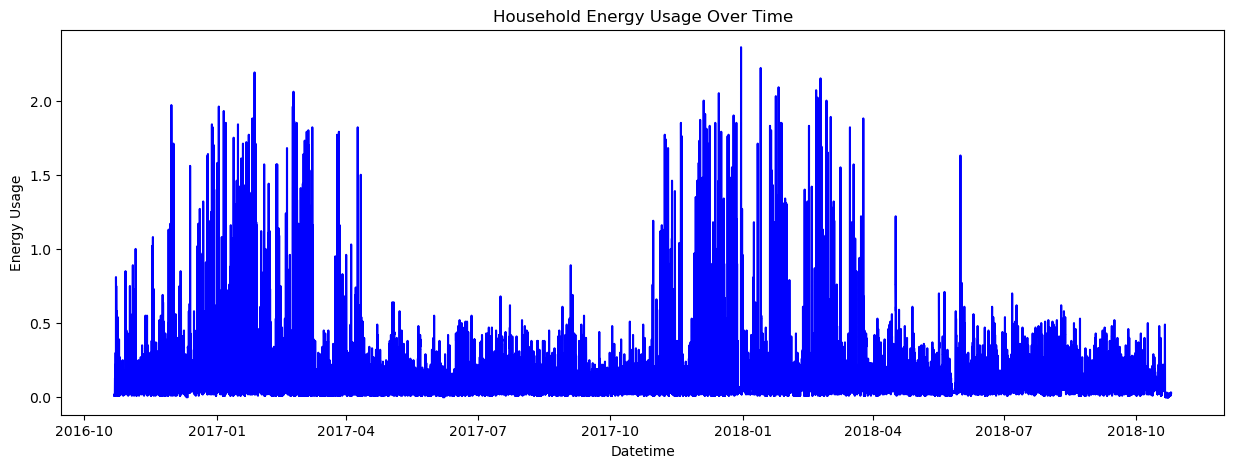

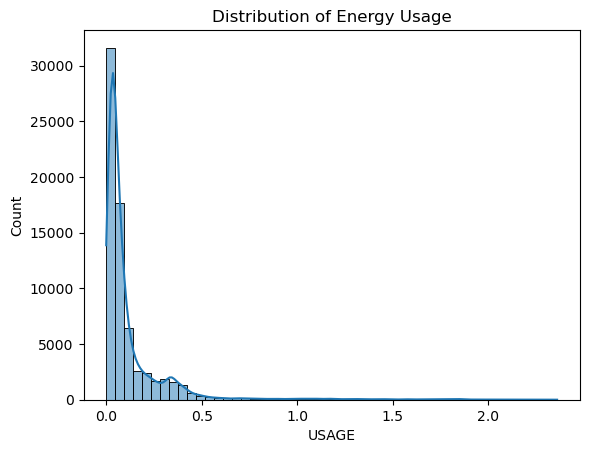

In [15]:
# Plot energy usage over time
plt.figure(figsize=(15,5))
plt.plot(dataset.index, dataset['USAGE'], color='blue')
plt.title('Household Energy Usage Over Time')
plt.xlabel('Datetime')
plt.ylabel('Energy Usage')
plt.show()

# Distribution of energy usage
sns.histplot(dataset['USAGE'], bins=50, kde=True)
plt.title('Distribution of Energy Usage')
plt.show()

USAGE Statistics:


count    70368.000000
mean         0.121941
std          0.210507
min          0.000000
25%          0.030000
50%          0.050000
75%          0.120000
max          2.360000
Name: USAGE, dtype: float64

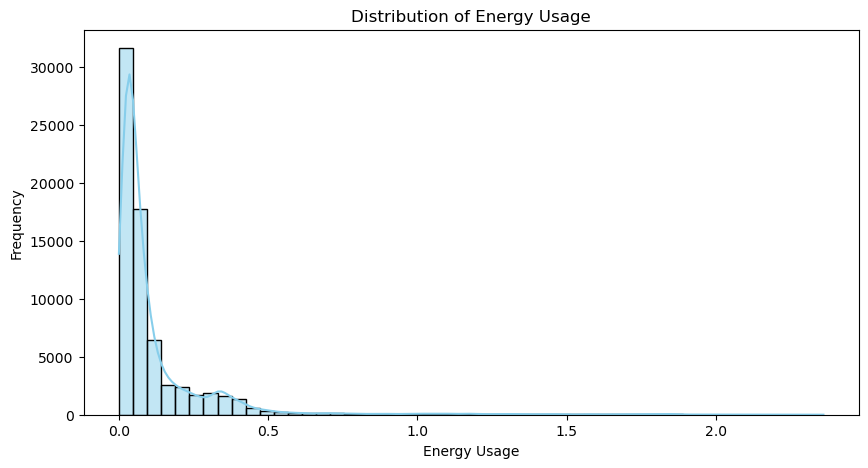

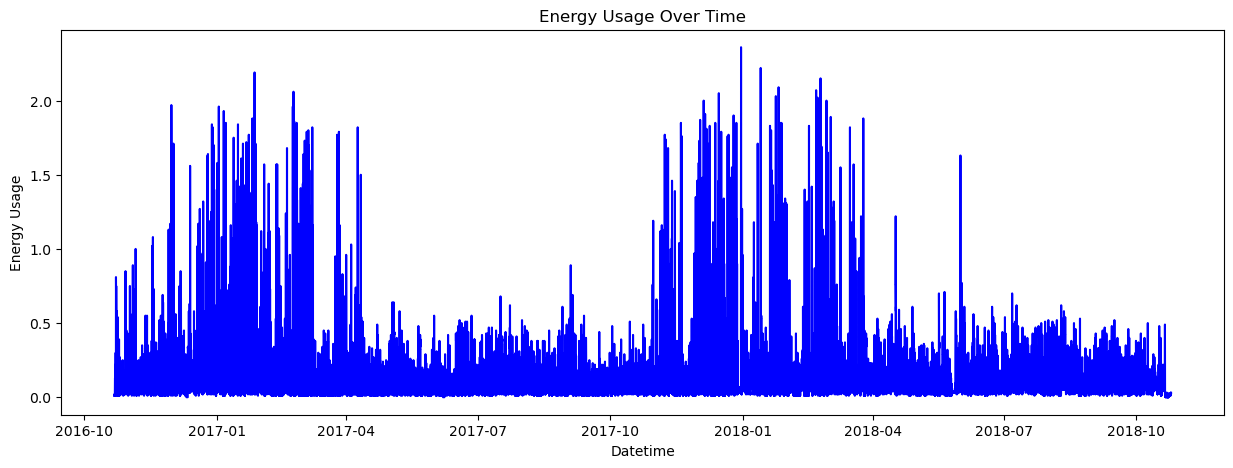

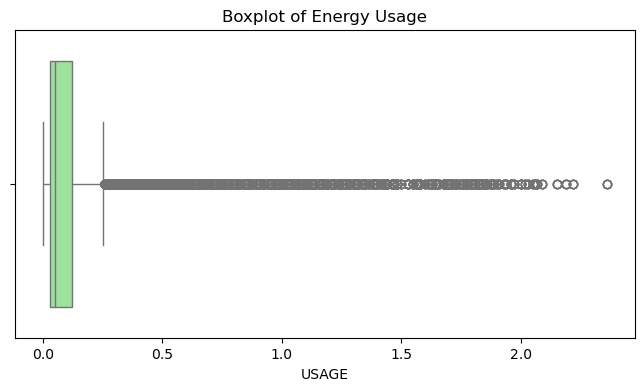

In [16]:
# Basic statistics
print("USAGE Statistics:")
display(dataset['USAGE'].describe())

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(dataset['USAGE'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Energy Usage')
plt.xlabel('Energy Usage')
plt.ylabel('Frequency')
plt.show()

# Plot time series
plt.figure(figsize=(15,5))
plt.plot(dataset['USAGE'], color='blue')
plt.title('Energy Usage Over Time')
plt.xlabel('Datetime')
plt.ylabel('Energy Usage')
plt.show()

# Boxplot to check outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=dataset['USAGE'], color='lightgreen')
plt.title('Boxplot of Energy Usage')
plt.show()

Unique UNITS values: ['kWh']
UNITS
kWh    70368
Name: count, dtype: int64


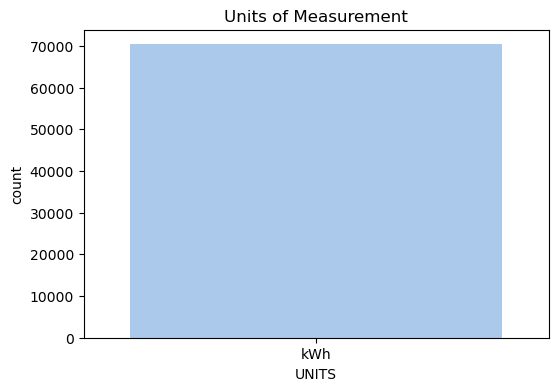

In [17]:
# Unique values
print("Unique UNITS values:", dataset['UNITS'].unique())

# Value counts
print(dataset['UNITS'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='UNITS', data=dataset, palette='pastel')
plt.title('Units of Measurement')
plt.show()

COST Statistics:


count      70368
unique        49
top       $0.01 
freq       30204
Name: COST, dtype: object

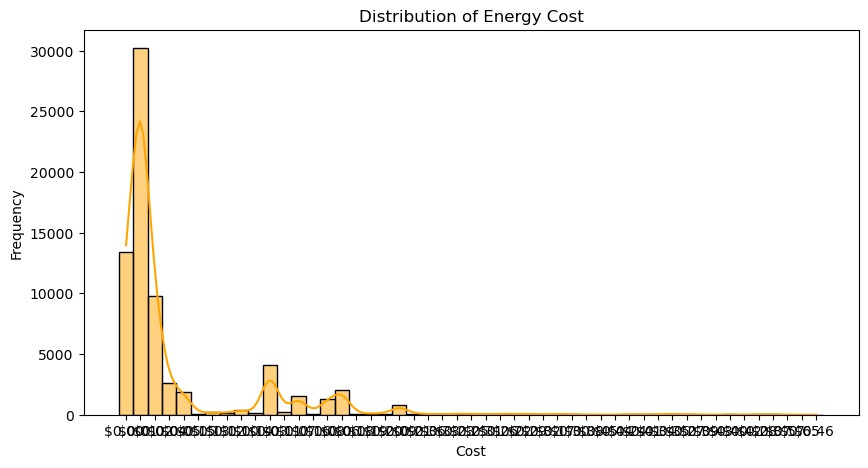

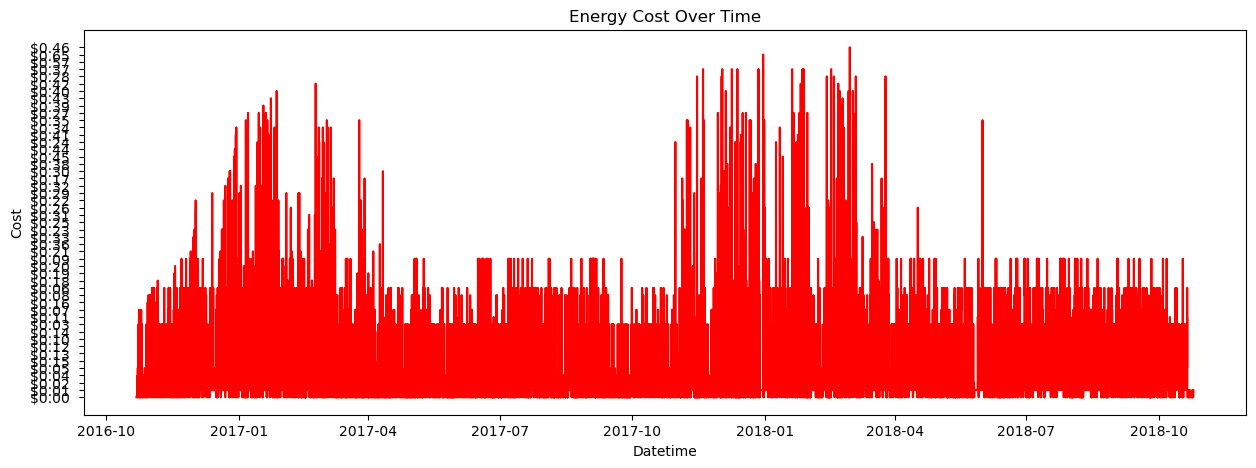

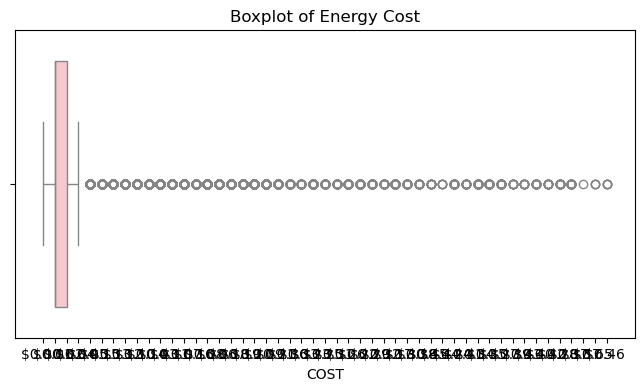

In [18]:
# Basic statistics
print("COST Statistics:")
display(dataset['COST'].describe())

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(dataset['COST'], bins=50, kde=True, color='orange')
plt.title('Distribution of Energy Cost')
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.show()

# Plot time series
plt.figure(figsize=(15,5))
plt.plot(dataset['COST'], color='red')
plt.title('Energy Cost Over Time')
plt.xlabel('Datetime')
plt.ylabel('Cost')
plt.show()

# Boxplot to check outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=dataset['COST'], color='pink')
plt.title('Boxplot of Energy Cost')
plt.show()

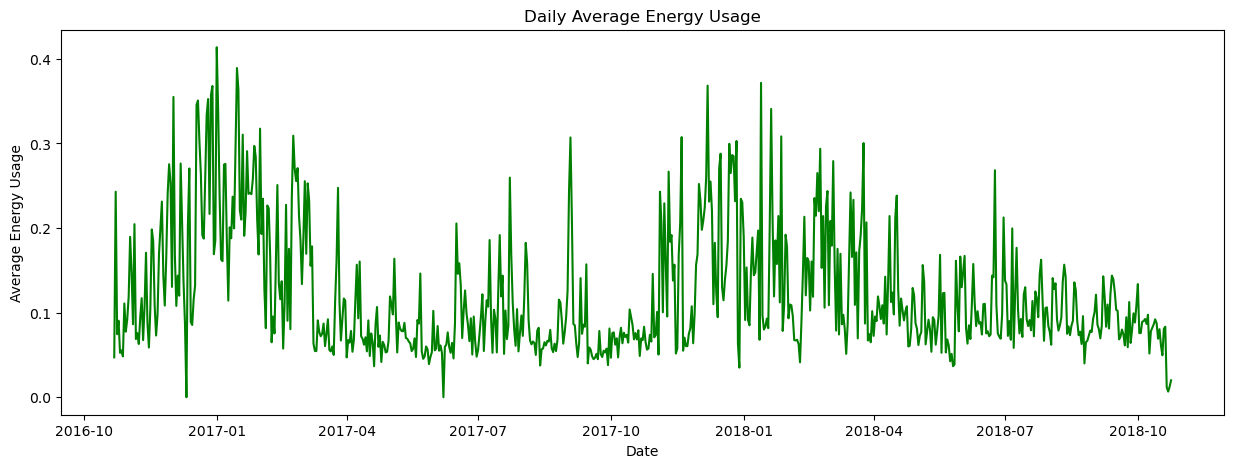

In [20]:
# Daily average usage
daily_usage = dataset['USAGE'].resample('D').mean()

plt.figure(figsize=(15,5))
plt.plot(daily_usage, color='green')
plt.title('Daily Average Energy Usage')
plt.xlabel('Date')
plt.ylabel('Average Energy Usage')
plt.show()

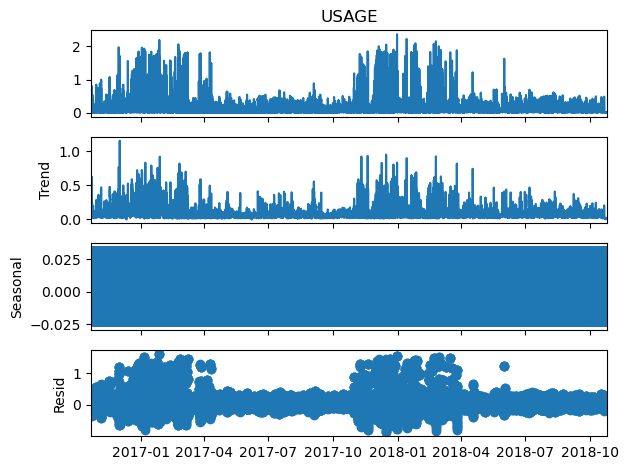

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(dataset['USAGE'], model='additive', period=24)  # period depends on frequency
result.plot()
plt.show()